In [1]:
import sys
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add dirctory with model moduels to path
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

import CIBUSmod as cm
from CIBUSmod.utils.output_data_manip import concat_herds

# Create input data
x0_crp.csv and x0_ani.csv represent the current areas of different crops and number of heads of different animals respectively. These are both still WIP, which is why some mangling is needed here to get them in the right form.
The demand vector is generated with demand for cattle meat, pig meat and cattle milk equal to what is in the agricultural statistics.

In [234]:
# Define x0_crp
x0_crp = \
    pd.read_csv(os.path.join('..','data','x0','x0_crp.csv'), dtype={'region': object})\
    .set_index(['crop','prod_system','region'])['area']

# Define x0_ani
x0_ani = pd.read_csv(os.path.join('..','data','x0','x0_ani.csv'), dtype={'region': object})

x0_ani['species'] = np.nan
x0_ani['species'] = \
np.where(np.isin(x0_ani['animal'], ['kor för mjölkproduktion', 'kor för uppfödning av kalvar']),'cattle',x0_ani['species'])
x0_ani['species'] = \
np.where(x0_ani['animal']=='suggor för avel','pigs',x0_ani['species'])

x0_ani['breed'] = np.nan
x0_ani['breed'] = \
np.where(x0_ani['animal']=='kor för mjölkproduktion','dairy',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='kor för uppfödning av kalvar','beef',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='suggor för avel','none',x0_ani['breed'])

x0_ani = x0_ani[x0_ani['species']!='nan'][['species','breed','prod_system','region','number']].set_index(['species','breed','prod_system','region'])['number']

x0_ani = x0_ani.fillna(0)

x0 = {'ani':x0_ani,'crp':x0_crp}

# Run base year
This runs the model for the base year (2016-2020). Results are then compared to statistics to ensure feasible results replicating the current situation.

In [254]:
# Instantiate diet class
diet = cm.Diet(
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','Diet.xlsx')
    )
)

# Instantiate crop production
crops = cm.CropProduction(
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','CropProduction.xlsx')
    ),
    index = x0_crp.index
)    

# Instantiate animal herds
herds=pd.Series(
    data=[],
    index=pd.MultiIndex(
        levels=[[]]*4,
        codes=[[]]*4,
        names=['species','breed','prod_system','sub_system']
    ),
    dtype = object
)

for (sp,br,ps) in x0_ani.groupby(['species','breed','prod_system']).sum().index:
            
    if sp == 'cattle':
        herds[(sp,br,ps,'none')] = \
            cm.CattleHerd(
                par = cm.ParameterRetriever(
                    os.path.join('..','data','prod_parameters','CattleHerd.xlsx')
                ),
                index = x0_ani.index.get_level_values('region').unique(),
                breed = br,
                prod_system = ps
            )

    elif sp == 'pigs':
        herds[(sp,br,ps,'none')] = \
            cm.PigHerd(
                par = cm.ParameterRetriever(
                    os.path.join('..','data','prod_parameters','PigHerd.xlsx')
                ),
                index = x0_ani.index.get_level_values('region').unique(),
                breed = br,
                prod_system = ps
            ) 

# Instantiate manure management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','FeedMgmt.xlsx')
    )
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','ManureMgmt.xlsx')
    )
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(x0,diet,crops,herds,feed_mgmt)

# -------------------------------------------------------------------- #

# Calculate food demand
diet.calculate(verbose=True)

# Calculate crops
crops.calculate(
    verbose = True
)

# Calculate herds
for h in herds:
    h.calculate(verbose = True)

# Calculate feed
feed_mgmt.calculate(verbose=True)    

# Calculate manure
manure_mgmt.calculate(verbose=True)

[15:53:32][Diet] Calculating food demand ...
[15:53:32][Diet] Calculating waste ...
[15:53:32][Diet] Calculating crop product demand ...
[15:53:32][Diet] Calculating crop product demand ...
[15:53:32][Diet] Done! Elapsed time: 0 sec
[15:53:32][CropProduction] Calculating harvest ...
[15:53:32][CropProduction] Calculating production ...
[15:53:33][CropProduction] Done! Elapsed time: 1 sec
[15:53:33][AnimalHerd (cattle, beef, conventional, none)] Calculating herd structure ...
[15:53:34][AnimalHerd (cattle, beef, conventional, none)] Calculating production ...
[15:53:34][AnimalHerd (cattle, beef, conventional, none)] Done! Elapsed time: 0 sec
[15:53:34][AnimalHerd (cattle, beef, organic, none)] Calculating herd structure ...
[15:53:34][AnimalHerd (cattle, beef, organic, none)] Calculating production ...
[15:53:35][AnimalHerd (cattle, beef, organic, none)] Done! Elapsed time: 1 sec
[15:53:35][AnimalHerd (cattle, dairy, conventional, none)] Calculating herd structure ...
[15:53:35][AnimalH

In [259]:
# Distribute animals and crops
geodist.make(use_cons=[1,2,3,4], scaling='item', verbose=True)

[15:54:54][GeoDist.make] Scaling ...
[15:54:54][GeoDist.make] Making constraint C1 ...
[15:55:00][GeoDist.make] Making constraint C2 ...
[15:56:21][GeoDist.make] Making constraint C3 ...
[15:56:21][GeoDist.make] Making constraint C4 ...
[15:56:21][GeoDist.make] Making objective O1 ...
[15:56:21][GeoDist.make] Defining problem ...
[15:56:21][GeoDist.make] Done! Elapsed time: 87 sec


In [260]:
geodist.solve(
    verbose=True,
    solver_settings = {
        'solver':'OSQP',
        'max_iter':100000,
        'eps_abs':1e-4,
        'eps_rel':1e-4,
        'verbose':False
    }
)

[15:56:21][GeoDist.solve] Finding solution ...
[15:56:41][GeoDist.solve] Optimal solution found! Status: 'optimal', Solver: 'OSQP'
[15:56:41][GeoDist.solve] Done! Elapsed time: 20 sec


In [261]:
# Scale and store results
out_crops = crops.scale(geodist.x['crp'])

out_animals = concat_herds([
    h.scale(
        geodist.x['ani'].loc[(h.species,h.breed,h.prod_system,h.sub_system)],
        x_is = h.x_is
    )
    for h in herds
])

# Check solution

### Check constraints

In [262]:
C1_atol = 10 # [kg]
C1_rtol = 0.01/100 # 0.01%

C2_tol = 10 # [kg]

C3_atol = 10 # [ha]
C3_rtol = 0.01/100 # 0.01%

C4_atol = 10 # [ha]
C4_rtol = 0.01/100 # 0.01%

C1_pass = np.isclose(
    geodist.A1.M @ np.concatenate((geodist.xs['ani'].values,geodist.xs['crp'].values)),
    geodist.b1,
    rtol=C1_rtol, atol=C1_atol
)

C2_pass = (
    geodist.A2.M @ np.concatenate((geodist.xs['ani'].values,geodist.xs['crp'].values))
    >= -C2_tol
)

C3_pass = (
    geodist.A3.M @ np.concatenate((geodist.xs['ani'].values,geodist.xs['crp'].values))
    - (C3_atol + geodist.b3*(1+C3_rtol))
    <= 0
)

C4_pass = (
    geodist.A4.M @ np.concatenate((geodist.xs['ani'].values,geodist.xs['crp'].values))
    - (C4_atol + geodist.b4*(1+C4_rtol))
    <= 0
)

if not C1_pass.all():
    print('C1 animals:')
    print(geodist.A1.rows['ani'][~C1_pass[:len(geodist.D['ani'])]])
    
    print('C1 crops:')
    print(geodist.A1.rows['crp'][~C1_pass[len(geodist.D['ani']):]])
    
if not C2_pass.all():
    print('C2:')
    print(geodist.A2.rows[~C2_pass])
    
if not C3_pass.all():
    print('C3:')
    print(geodist.A3.rows[~C3_pass])
    
if not C4_pass.all():
    print('C4:')
    print(geodist.A4.rows[~C4_pass])

C2:
MultiIndex([( 'fodder', 'conventional', '1112'),
            ( 'fodder', 'conventional', '1617'),
            ( 'fodder', 'conventional', '2019'),
            ( 'fodder', 'conventional', '2331'),
            ( 'fodder', 'conventional', '2419'),
            ( 'fodder',      'organic', '1321'),
            (  'wheat', 'conventional',  '812'),
            (  'wheat', 'conventional',  '913'),
            (  'wheat', 'conventional', '1617'),
            ('grazing', 'conventional',  '513'),
            ('grazing', 'conventional', '2019')],
           )


In [263]:
# Check constraint C1 (production meets demand)
round(pd.Series(
    geodist.A1.M @ np.concatenate((geodist.xs['ani'].values,geodist.xs['crp'].values)) - geodist.b1,
    index=np.concatenate((geodist.A1.rows['ani'].values,geodist.A1.rows['crp'].values))
)/1000,2)

(conventional, cattle, meat)       0.00
(conventional, cattle, milk)       0.00
(conventional, pigs, meat)        -0.00
(organic, cattle, meat)            0.00
(organic, cattle, milk)            0.00
(organic, pigs, meat)              0.00
(conventional, wheat)              0.00
(conventional, barley)             0.00
(conventional, rye)                0.00
(conventional, oats)               0.00
(conventional, potatoes table)     0.00
(conventional, potatoes starch)   -0.00
(conventional, tomatoes)          -0.00
(conventional, cucumbers)         -0.00
(organic, wheat)                  -0.00
(organic, barley)                  0.00
(organic, rye)                    -0.00
(organic, oats)                   -0.00
(organic, potatoes table)         -0.00
(organic, potatoes starch)        -0.00
(organic, tomatoes)                0.00
(organic, cucumbers)               0.00
(conventional, fodder)            -0.00
(organic, fodder)                  0.00
(conventional, maize fodder)       0.00


Check output tables that production meets demand

Prod - Diet - Feed = 0

In [264]:
# Check if crop production meets demand [tonnes]
tmp = pd.concat([
    # Crop production
    out_crops.production.rename_axis(columns='crop_prod').stack().groupby(['prod_system','crop_prod']).sum().rename('prod'),
    # Diet demand
    -geodist.D['crp'].rename('diet'),
    # Feed demand
    -out_animals.feed.crop_product_demand
    .xs('domestic',level='origin',axis=1)
    .groupby(['prod_system','crop_prod'],axis=1)
    .sum().sum()
    .rename('feed')
], axis=1)
tmp['sum'] = tmp.sum(axis=1)
round(tmp/1000,1)


prod      diet       feed  sum
prod_system  crop_prod                                           
conventional maize fodder           0.0      -0.0        NaN  0.0
             fodder           1884485.2      -0.0 -1884485.2 -0.0
             grazing           657086.6      -0.0  -657086.6 -0.0
             wheat            2230409.3 -501666.2 -1728743.0  0.0
             barley            125206.5 -125206.5        NaN  0.0
             rye                74057.6  -74057.6        NaN  0.0
             oats               47188.7  -47188.7        NaN  0.0
             potatoes table    720675.9 -720675.9        NaN  0.0
             potatoes starch    28029.1  -28029.1        NaN -0.0
             cucumbers          40566.7  -40566.7        NaN -0.0
             tomatoes           19437.5  -19437.5        NaN -0.0
organic      maize fodder           0.0      -0.0        NaN  0.0
             fodder            417841.4      -0.0  -417841.4  0.0
             grazing           163770.1      -0.0  -163770.1 -0.0
             wheat             235088.3  -28076.4  -207012.0 -0.0
             barley              6451.2   -6451.2        NaN  0.0
             rye                10773.6  -10773.6        NaN -0.0
             oats                8788.4   -8788.4        NaN -0.0
             potatoes table     37930.3  -37930.3        NaN -0.0
             potatoes starch     1475.2   -1475.2        NaN -0.0
             cucumbers            409.8    -409.8        NaN  0.0
             tomatoes             196.3    -196.3        NaN  0.0

In [265]:
# Check if animal production meets demand [tonnes]

tmp = pd.concat([
    # Animal production
    out_animals.production.groupby(['prod_system','species','animal_prod'],axis=1).sum().sum().rename('prod'),
    # Diet demand
    -geodist.D['ani'].rename('diet'),
],axis=1)
tmp['sum'] = tmp.sum(axis=1)
round(tmp/1000,1)

prod       diet  sum
prod_system  species animal_prod                           
conventional cattle  meat          126570.6  -126570.6  0.0
                     milk         2174142.2 -2174142.2  0.0
             pigs    meat          242188.1  -242188.1 -0.0
organic      cattle  meat           23040.0   -23040.0  0.0
                     milk          445306.2  -445306.2  0.0
             pigs    meat            5955.4    -5955.4  0.0

### Check deviations from x0

In [266]:
print('Crops max(x-x0) [ha]:',(geodist.x['crp'] - geodist.x0['crp']).max())
print('Crops min(x-x0) [ha]:',(geodist.x['crp'] - geodist.x0['crp']).min())
print('Animals max(x-x0) [nr]:',(geodist.x['ani'] - geodist.x0['ani']).max())
print('Animals min(x-x0) [nr]:',(geodist.x['ani'] - geodist.x0['ani']).min())

Crops max(x-x0) [ha]: 702.8751201717354
Crops min(x-x0) [ha]: -8717.183221898855
Animals max(x-x0) [nr]: 695.5599423915371
Animals min(x-x0) [nr]: -545.1422196902049


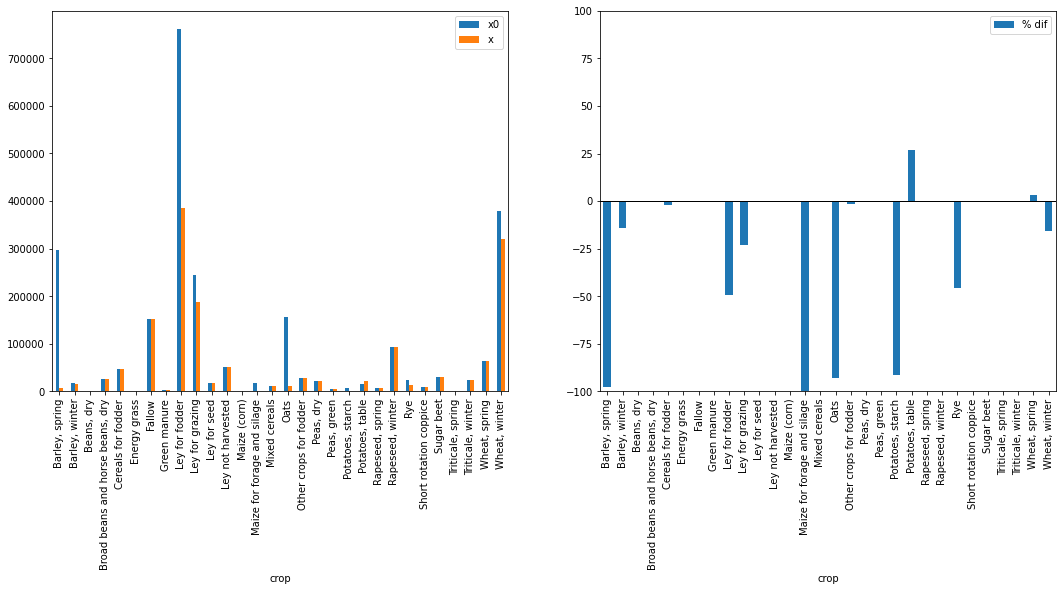

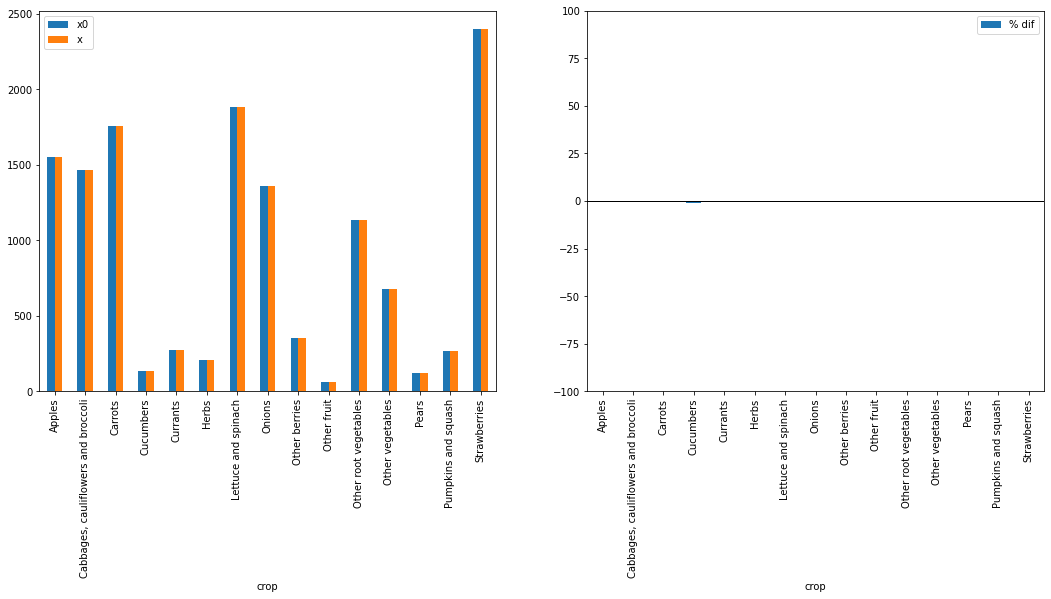

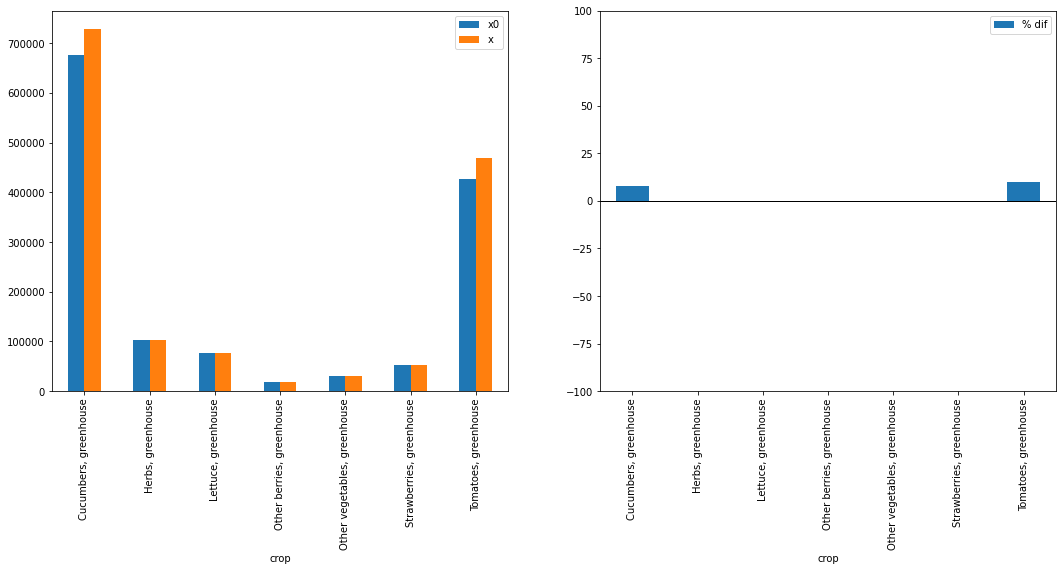

In [267]:
plot_data = (
    pd.concat([
        out_crops.area.groupby('crop').sum().rename('x'),
        x0_crp.groupby('crop').sum().rename('x0')
    ], axis=1)
    .apply(
        lambda x:
        pd.Series(
            [
                x['x'],
                x['x0'],
                ((x['x']-x['x0'])/x['x0']*100)
            ],
            index = ['x','x0','% dif']
        ),
        axis=1
    )
)

cg_dict = crops.par.get_rel('crop','crop_group')
plot_data['cg'] = [cg_dict[c] for c in plot_data.index.get_level_values(0)]

hr = ['Vegetables','Berries','Fruit trees']
gh = ['Vegetables, greenhouse','Berries, greenhouse']
sng = ['Semi-natural grasslands']

fig, axs = plt.subplots(1,2, figsize=(18,7))
plot_data[~plot_data['cg'].isin(hr+gh+sng)].plot.bar(y=['x0','x'], ax=axs[0])
plot_data[~plot_data['cg'].isin(hr+gh+sng)].plot.bar(y='% dif', ax=axs[1])
plt.axhline(y=0, c='black', lw=1)
axs[1].set_ylim(-100,100)
plt.show()

fig, axs = plt.subplots(1,2, figsize=(18,7))
plot_data[plot_data['cg'].isin(hr)].plot.bar(y=['x0','x'], ax=axs[0])
plot_data[plot_data['cg'].isin(hr)].plot.bar(y='% dif', ax=axs[1])
plt.axhline(y=0, c='black', lw=1)
axs[1].set_ylim(-100,100)
plt.show()

fig, axs = plt.subplots(1,2, figsize=(18,7))
plot_data[plot_data['cg'].isin(gh)].plot.bar(y=['x0','x'], ax=axs[0])
plot_data[plot_data['cg'].isin(gh)].plot.bar(y='% dif', ax=axs[1])
plt.axhline(y=0, c='black', lw=1)
axs[1].set_ylim(-100,100)
plt.show()

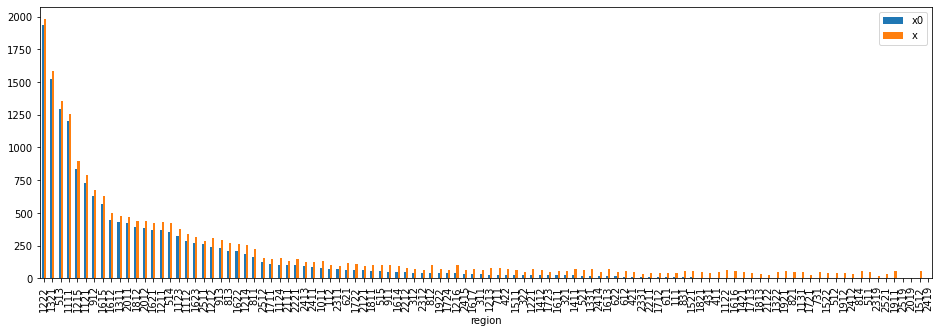

In [228]:
crp = 'Barley, spring'

fig, ax = plt.subplots(figsize=(16,5))

pd.concat([
    geodist.x0['crp'].xs(crp, level='crop').groupby('region').sum().rename('x0'),
    out_crops.area.xs(crp, level='crop').groupby('region').sum().rename('x')
], axis=1).sort_values('x0', ascending=False).plot.bar(ax=ax)

plt.show()

In [229]:


print(
    pd.concat([
        out_animals.heads
        .groupby(['species','breed','prod_system','animal'], axis=1).sum()
        .sum().loc[idx[:,:,:,['cows','sows']]].droplevel('animal')
        .rename('x')
        ,
        x0_ani
        .groupby(['species','breed','prod_system']).sum()
        .rename('x0')
    ], axis=1)
    .apply(
        lambda x:
        pd.Series(
            [x['x'].round(1),x['x0'].round(1),((x['x']-x['x0'])/x['x0']*100).round(1)],
            index = ['x','x0','% dif']
        ),
        axis=1
    )
)

                                   x        x0  % dif
species breed prod_system                            
cattle  beef  conventional  199560.4  128080.1   55.8
              organic        63273.1   72274.4  -12.5
        dairy conventional  233433.0  263227.4  -11.3
              organic        52369.2   54920.6   -4.6
pigs    none  conventional  101409.5  132262.5  -23.3
              organic         3426.8    3325.0    3.1


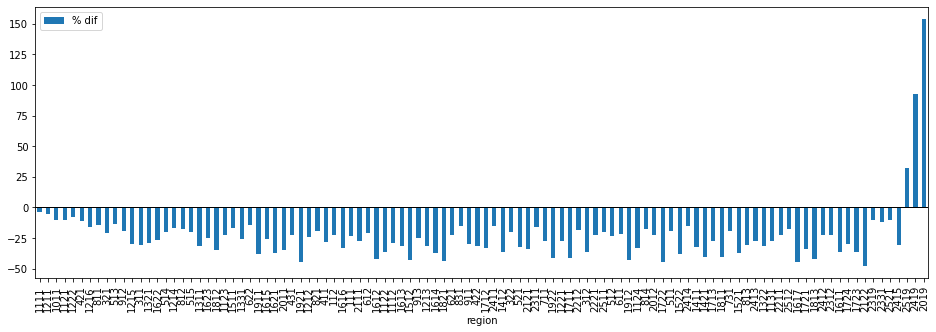

In [230]:
fig, ax = plt.subplots(figsize=(16,5))
(pd.concat([
    out_crops.area.groupby('region').sum().rename('x'),
    x0_crp.groupby('region').sum().rename('x0')
], axis=1)
.apply(
    lambda x:
    pd.Series(
        [x['x'],x['x0'],((x['x']-x['x0'])/x['x0']*100)],
        index = ['x','x0','% dif']
    ),
    axis=1
)).sort_values('x0', ascending=False).plot.bar(y='% dif', ax=ax)
plt.axhline(y=0, c='black', lw=1)
plt.show()

<AxesSubplot:xlabel='species,breed,prod_system'>

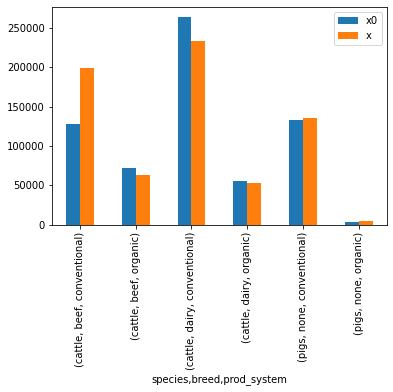

In [231]:
idx = pd.IndexSlice
(pd.concat([
    out_animals.heads.rename({'gilts':'sows'}, axis=1)
    .groupby(['species','breed','prod_system','animal'], axis=1).sum()
    .sum().loc[idx[:,:,:,['cows','sows']]].droplevel('animal')
    .rename('x')
    ,
    x0_ani
    .groupby(['species','breed','prod_system']).sum()
    .rename('x0')
], axis=1)
.apply(
    lambda x:
    pd.Series(
        [x['x'].round(1),x['x0'].round(1),((x['x']-x['x0'])/x['x0']*100).round(1)],
        index = ['x','x0','% dif']
    ),
    axis=1
)).plot.bar(y=['x0','x'])